# v10: PanDerm LP + Fitzpatrick17k + Temperature Scaling + 閾値最適化 + DDI評価

**概要:** PanDerm ViT-Large (backbone凍結) に、Fitzpatrick17k の腫瘍クラスのみを抽出した
6クラスでLinear Probingを訓練。TS → 閾値最適化 → Fitz test + DDI 多条件評価。

**6クラス（腫瘍クラスのみ）:**
- 悪性3: malignant melanoma, malignant epidermal, malignant dermal
- 良性3: benign epidermal, benign dermal, benign melanocyte

**実験設計:**
- TS・閾値最適化は Fitz **valセット** で実施（DDIはテストセット扱い → 使わない）
- **順序:** TS → 閾値最適化（理由: 6クラス→binary集約では softmax(z/T) の sum が
  単調変換にならないため、TSが確率の相対順序を変えうる。
  未較正probsで決めた閾値はTS後に最適でなくなる可能性がある）


In [1]:
import random
import torch
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False


### ライブラリ読み込み

In [2]:
%matplotlib inline
import os, cv2, itertools, time, copy, json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
from glob import glob
from PIL import Image
from pathlib import Path
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

import warnings
warnings.filterwarnings('ignore', message='Overwriting.*in registry')
warnings.filterwarnings('ignore', category=FutureWarning, module='timm')
warnings.filterwarnings('ignore', message='torch.meshgrid')

from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    roc_curve, auc, precision_recall_fscore_support,
    precision_score, recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

DATA_DIR = Path('../data/fitzpatrick17k')
IMG_DIR  = DATA_DIR / 'images'
df = pd.read_csv(DATA_DIR / 'fitzpatrick17k.csv')
print(f'Loaded: {len(df)} rows')


Device: cuda:0
Loaded: 16577 rows


## 1. Fitzpatrick17kデータ前処理

In [3]:
# QCフィルタ
if 'qc' in df.columns:
    before = len(df)
    df = df[~df['qc'].isin(['3 Wrongly labelled', '4 Other'])].reset_index(drop=True)
    print(f'After QC filter: {len(df)} (removed {before - len(df)})')

before = len(df)
df = df[df['fitzpatrick_scale'] != -1].reset_index(drop=True)
print(f'After FST filter: {len(df)} (removed {before - len(df)})')

df['img_path'] = df['md5hash'].apply(lambda x: str(IMG_DIR / f'{x}.jpg'))
before = len(df)
df = df[df['img_path'].apply(os.path.exists)].reset_index(drop=True)
print(f'After image existence filter: {len(df)} (removed {before - len(df)})')

EXCLUDE_CLASSES = ['inflammatory', 'genodermatoses', 'malignant cutaneous lymphoma']
before = len(df)
df = df[~df['nine_partition_label'].isin(EXCLUDE_CLASSES)].reset_index(drop=True)
print(f'After tumor-only filter: {len(df)} (removed {before - len(df)}, excluded: {EXCLUDE_CLASSES})')

CLASS_NAMES_9   = sorted(df['nine_partition_label'].unique().tolist())
NUM_CLASSES     = len(CLASS_NAMES_9)
class_to_idx    = {c: i for i, c in enumerate(CLASS_NAMES_9)}
df['class_idx'] = df['nine_partition_label'].map(class_to_idx)
print(f'\n--- {NUM_CLASSES} classes (tumor only) ---')
for name in CLASS_NAMES_9:
    count = (df['nine_partition_label'] == name).sum()
    print(f'  {class_to_idx[name]}: {name:<35} {count:>5}')

MALIGNANT_CLASSES  = [c for c in CLASS_NAMES_9 if 'malignant' in c]
MALIGNANT_INDICES  = [class_to_idx[c] for c in MALIGNANT_CLASSES]
BENIGN_INDICES     = [i for i in range(NUM_CLASSES) if i not in MALIGNANT_INDICES]
df['is_malignant'] = df['nine_partition_label'].isin(MALIGNANT_CLASSES).astype(int)
print(f'\nMalignant classes: {MALIGNANT_CLASSES}')
print(f'Malignant: {df["is_malignant"].sum()}, Benign: {(1-df["is_malignant"]).sum()}')
print(f'\n--- FST x Malignant ---')
print(pd.crosstab(df['fitzpatrick_scale'], df['is_malignant'], margins=True))


After QC filter: 16550 (removed 27)
After FST filter: 15985 (removed 565)
After image existence filter: 12199 (removed 3786)
After tumor-only filter: 3173 (removed 9026, excluded: ['inflammatory', 'genodermatoses', 'malignant cutaneous lymphoma'])

--- 6 classes (tumor only) ---
  0: benign dermal                         869
  1: benign epidermal                      689
  2: benign melanocyte                     228
  3: malignant dermal                      108
  4: malignant epidermal                   814
  5: malignant melanoma                    465

Malignant classes: ['malignant dermal', 'malignant epidermal', 'malignant melanoma']
Malignant: 1387, Benign: 1786

--- FST x Malignant ---
is_malignant          0     1   All
fitzpatrick_scale                  
1                   433   363   796
2                   597   547  1144
3                   353   241   594
4                   246   131   377
5                   119    65   184
6                    38    40    78
All      

In [4]:
duplicates = {
    '5f567374f688120109c2bab349ff21cf': '22f1d783dd6821defafcc915a8146c41',
    '6de74d3051ceafe10cf3f3e8c342bad8': 'be030bdb35c3c8cbf9145dfcebc0c0d2',
    '19a1b36184861141cd3b1cd43e74b5b6': 'dbee4a80595e78f281e1a0938f9857be',
    'a7ef35e99387ff1227baced72467dc1f': '33068b46548282d53e5fee2f15792728',
    '6cd57e29acb9071a6c5e5aa23aeaf0ee': '11e1eeb117aafe575e95f9c2ee9de3f3',
    'adb5b7253c21d274f9b1a793b01b84d2': '3554761709cc4906ab9db13e5e46aa25',
    'ea7c258aade6d510197d02b8d5012ba5': 'e6b375b8b1b7e27706623977dace3721',
    '38682083d6f7539a88c17d57559dcbd6': '2b16c87c36fa56721ab867e53560ec9b',
    '1cc5a0ffcaf2f370cd65f10eeeb7fddd': '9b82bbff48d88f3bea9d30cfd96606dc',
    '8633a0075168ec7587c636bde73fcb21': '09d46db9589ff45436cda87c4abc946b',
    '771fff032a6c7854eb8509f5849e929e': 'bf77bafaa320f244f2331ca466b96f50',
    '95727ec19e5e87adf63dc241cb5e4af8': '9829c11b6a2ea0a47031a865d761a670',
    'a027f129d0ed0d55f8c0c455d9de0035': 'ba8e7927c71912e42cde00184b691376',
    'fd5dd82519cfa82bd6f23d9f83b421aa': '34b5d983d901815b931e28ee357ddf74',
    'bb7eaaccb79a069d59db68a3cae983cb': 'd519b2976ab7e3da9c334540018cad79',
    'f7a234c59d01011f64c9633409a30086': 'a36d079aeee1bd073859a3af6041c4f4',
    'a874b1654043ff9c19375a4b04be79a3': '8e4fcec9d635f8e9c152a23aad631eec',
    'fcb25afb92552dceba953b8254544a19': '0455b31fb640b89ee7375711168f318b',
    '5041af68a1e046acff0fc93da11de68f': '0e2a24d28767bea1a4a37d1c6a4d4f31',
    'bf0403884214daf1e41bdb522df8c8a1': '1efcd7e523f9cdf487d1be5ec88e546a',
    '59c60187f6e65c32cbbadbdfc8b8df1d': '8e8674abd53e4d087da3798f478edb8c',
    '81ccde6038a8c7bf6860774ebaf4bad8': '5eebe4328896867cce5c841d7d15d765',
    'e2e1cf7d3e85b5bcbb00223931f84487': 'd56d52145880b5280cc2d18c9b4a89f7',
}
remove_hashes = set(duplicates.values())
before = len(df)
df = df[~df['md5hash'].isin(remove_hashes)].reset_index(drop=True)
print(f'Dedup: {before} to {len(df)} (removed {before - len(df)} duplicates)')

df_trainval, df_test = train_test_split(
    df, test_size=0.15, random_state=42, stratify=df['class_idx']
)
df_train, df_val = train_test_split(
    df_trainval, test_size=0.176, random_state=42, stratify=df_trainval['class_idx']
)
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)
print(f'Train: {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}')
print(f'\nTrain class distribution:')
print(df_train['nine_partition_label'].value_counts().sort_index())


Dedup: 3173 to 3166 (removed 7 duplicates)
Train: 2217, Val: 474, Test: 475

Train class distribution:
nine_partition_label
benign dermal          608
benign epidermal       481
benign melanocyte      160
malignant dermal        76
malignant epidermal    568
malignant melanoma     324
Name: count, dtype: int64


## 2. PanDerm ViT-Large ロード

In [5]:
import importlib.util, sys

spec = importlib.util.spec_from_file_location(
    'modeling_finetune',
    os.path.expanduser('~/PanDerm/classification/models/modeling_finetune.py')
)
mf = importlib.util.module_from_spec(spec)
sys.modules['modeling_finetune'] = mf
spec.loader.exec_module(mf)

CKPT_PATH = os.path.expanduser('~/PanDerm/checkpoints/panderm_ll_data6_checkpoint-499.pth')
model_backbone = mf.panderm_large_patch16_224()
state_dict = torch.load(CKPT_PATH, map_location='cpu', weights_only=True)
state_dict = {k.replace('encoder.', ''): v for k, v in state_dict.items()}
missing, unexpected = model_backbone.load_state_dict(state_dict, strict=False)
print(f'Missing keys: {len(missing)} (head only — expected)')
if unexpected:
    print(f'⚠ Unexpected keys: {len(unexpected)}')
model_backbone.head = nn.Identity()
model_backbone = model_backbone.to(device)
model_backbone.eval()

with torch.no_grad():
    _t = torch.randn(1, 3, 224, 224).to(device)
    EMBED_DIM = model_backbone(_t).shape[1]
    print(f'Embedding dim: {EMBED_DIM}')
del _t


Missing keys: 2 (head only — expected)
⚠ Unexpected keys: 92
Embedding dim: 1024


In [6]:
# アーキテクチャ確認（確認後削除）
print(type(model_backbone.blocks[-1]))
print([name for name, _ in model_backbone.blocks[-1].named_modules()])

<class 'modeling_finetune.Block'>
['', 'norm1', 'attn', 'attn.qkv', 'attn.attn_drop', 'attn.proj', 'attn.proj_drop', 'drop_path', 'norm2', 'mlp', 'mlp.fc1', 'mlp.act', 'mlp.fc2', 'mlp.drop']


In [7]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.228, 0.224, 0.225)

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class FitzDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, index):
        row = self.df.iloc[index]
        with Image.open(row['img_path']) as img:
            X = img.convert('RGB').copy()
        if self.transform:
            X = self.transform(X)
        return X, row['class_idx']


## 3. 特徴抽出 + Linear Probing

In [8]:
def extract_features(model, dataloader, device):
    all_feats, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Extracting'):
            images = images.to(device)
            all_feats.append(model(images).cpu())
            all_labels.append(labels)
    return torch.cat(all_feats), torch.cat(all_labels)

train_loader = DataLoader(FitzDataset(df_train, eval_transform), batch_size=64, shuffle=False, num_workers=4)
val_loader   = DataLoader(FitzDataset(df_val,   eval_transform), batch_size=64, shuffle=False, num_workers=4)
test_loader  = DataLoader(FitzDataset(df_test,  eval_transform), batch_size=64, shuffle=False, num_workers=4)

start = time.time()
train_feats, train_labels = extract_features(model_backbone, train_loader, device)
val_feats,   val_labels   = extract_features(model_backbone, val_loader,   device)
test_feats,  test_labels  = extract_features(model_backbone, test_loader,  device)
print(f'Feature extraction: {time.time()-start:.1f}s')
print(f'Train: {train_feats.shape}, Val: {val_feats.shape}, Test: {test_feats.shape}')

del model_backbone
torch.cuda.empty_cache()
print('Backbone released')


Extracting: 100%|███████████████████████| 8/8 [00:05<00:00,  1.41it/s]

Feature extraction: 31.6s
Train: torch.Size([2217, 1024]), Val: torch.Size([474, 1024]), Test: torch.Size([475, 1024])
Backbone released


In [9]:
from sklearn.linear_model import LogisticRegression

lam      = EMBED_DIM * NUM_CLASSES / 100
C_sklearn = 1.0 / lam
print(f'LP: solver=lbfgs, lambda={lam:.2f}, C={C_sklearn:.5f}')

X_train = train_feats.numpy(); y_train = train_labels.numpy()
X_val   = val_feats.numpy();   y_val   = val_labels.numpy()

clf = LogisticRegression(C=C_sklearn, solver='lbfgs', max_iter=1000, random_state=42)
clf.fit(X_train, y_train)
print(f'Val accuracy: {clf.score(X_val, y_val):.4f}')

# nn.Linearに変換（保存・推論用）
linear_head = nn.Linear(EMBED_DIM, NUM_CLASSES)
linear_head.weight.data = torch.tensor(clf.coef_, dtype=torch.float32)
linear_head.bias.data   = torch.tensor(clf.intercept_, dtype=torch.float32)
linear_head = linear_head.to(device)
linear_head.eval()
print('linear_head (nn.Linear) 変換完了')


LP: solver=lbfgs, lambda=61.44, C=0.01628
Val accuracy: 0.7152
linear_head (nn.Linear) 変換完了


## 4. テストセット評価

In [10]:
# ============================================================
# Test: 6クラス評価
# ============================================================
test_feats_gpu = test_feats.to(device)
with torch.no_grad():
    test_logits = linear_head(test_feats_gpu)
    test_probs  = F.softmax(test_logits, dim=1).cpu().numpy()

y_true        = test_labels.numpy()
y_pred        = test_probs.argmax(axis=1)
y_true_onehot = label_binarize(y_true, classes=range(NUM_CLASSES))

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES_9, digits=3))
roc_auc_macro = roc_auc_score(y_true_onehot, test_probs, multi_class='ovr', average='macro')
print(f'ROC-AUC macro (6-class): {roc_auc_macro:.4f}')


                     precision    recall  f1-score   support

      benign dermal      0.669     0.731     0.699       130
   benign epidermal      0.656     0.592     0.622       103
  benign melanocyte      0.762     0.471     0.582        34
   malignant dermal      0.778     0.438     0.560        16
malignant epidermal      0.737     0.828     0.780       122
 malignant melanoma      0.671     0.700     0.685        70

           accuracy                          0.693       475
          macro avg      0.712     0.626     0.655       475
       weighted avg      0.694     0.693     0.688       475

ROC-AUC macro (6-class): 0.9263


### 二値集約（malignant/benign）+ ROC曲線

Binary AUC (Fitz test): 0.9089
Malignant: 208, Benign: 267


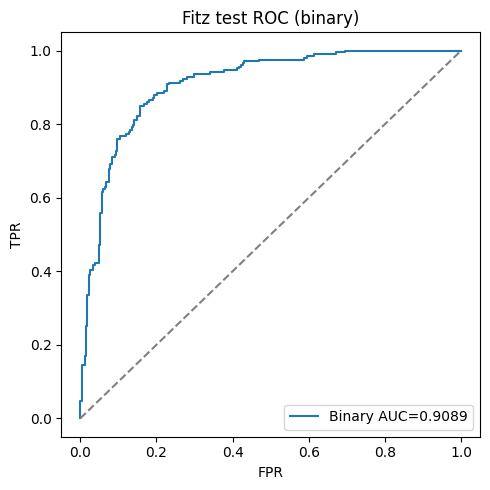

Saved: results/v10/fig_binary_roc.png


In [11]:
# ============================================================
# Binary集約: malignant 3クラスの確率和 → binary AUC
# ============================================================
p_mal_test   = test_probs[:, MALIGNANT_INDICES].sum(axis=1)
y_true_binary = np.isin(y_true, MALIGNANT_INDICES).astype(int)
binary_auc   = roc_auc_score(y_true_binary, p_mal_test)
print(f'Binary AUC (Fitz test): {binary_auc:.4f}')
print(f'Malignant: {y_true_binary.sum()}, Benign: {(1-y_true_binary).sum()}')

# ROC曲線
fpr_test, tpr_test, _ = roc_curve(y_true_binary, p_mal_test)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr_test, tpr_test, label=f'Binary AUC={binary_auc:.4f}')
ax.plot([0,1],[0,1],'--', color='gray')
ax.set(xlabel='FPR', ylabel='TPR', title='Fitz test ROC (binary)')
ax.legend()
plt.tight_layout()
V10_DIR_fig = Path('../results/v10'); V10_DIR_fig.mkdir(exist_ok=True)
plt.savefig(V10_DIR_fig / 'fig_binary_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: results/v10/fig_binary_roc.png')


### 成果物保存

In [12]:
V10_DIR     = Path('../results/v10'); V10_DIR.mkdir(exist_ok=True)
RESULTS_DIR = Path('../results/models'); RESULTS_DIR.mkdir(exist_ok=True)
os.makedirs('../models', exist_ok=True)

NB_NAME   = 'v10'
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Linear head保存
head_path = f'../models/panderm_lp_head_{NB_NAME}_fitz_tumor_{timestamp}.pth'
torch.save(linear_head.state_dict(), head_path)
print(f'Head saved: {head_path}')

# val logits計算（TS・閾値最適化・保存セルで使用）
val_feats_gpu = val_feats.to(device)
with torch.no_grad():
    val_logits_tensor = linear_head(val_feats_gpu)
    val_probs_arr     = F.softmax(val_logits_tensor, dim=1).cpu().numpy()
    val_logits_arr    = val_logits_tensor.cpu().numpy()
print('val_logits_arr ready')


Head saved: ../models/panderm_lp_head_v10_fitz_tumor_20260312_205219.pth
val_logits_arr ready


## 5. Temperature Scaling

**順序の根拠:** 6クラス → binary集約（malignant 3クラスのsum）では、
`sum(softmax(z/T))` は `sum(softmax(z))` の単調変換にならない。
TSが確率の相対順序を変えうるため、TS後のprobsに対して閾値を最適化する必要がある。

v5（HAM、T=1.36）では T が 1 に近くECEがほぼ不変だったため順序の乱れが実質ゼロだった。
PanDerm v8 の T=0.66 は 1 から大きく離れるため v10 では順序が重要になる。


In [13]:
# ============================================================
# ECE計算ユーティリティ（binary malignant集約確率）
# ============================================================
def compute_ece_binary(probs_mal, labels_bin, n_bins=15):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for b in range(n_bins):
        lo, hi = bins[b], bins[b+1]
        m = (probs_mal >= lo) & (probs_mal < hi)
        if m.sum() == 0:
            continue
        ece += m.sum() * abs(labels_bin[m].mean() - probs_mal[m].mean())
    return ece / len(probs_mal)

val_y_bin        = np.isin(val_labels.numpy(), MALIGNANT_INDICES).astype(int)
val_p_mal_before = val_probs_arr[:, MALIGNANT_INDICES].sum(axis=1)
ece_before       = compute_ece_binary(val_p_mal_before, val_y_bin)
print(f'ECE before TS: {ece_before:.4f}')


ECE before TS: 0.0523


In [14]:
# ============================================================
# Temperature Scaling: L-BFGSでT最適化
# ============================================================
logits_val_t = torch.tensor(val_logits_arr, dtype=torch.float32)
labels_val_t = torch.tensor(val_labels.numpy(), dtype=torch.long)

temperature  = nn.Parameter(torch.ones(1, requires_grad=True))
opt_ts       = optim.LBFGS([temperature], lr=0.01, max_iter=100)

def ts_closure():
    opt_ts.zero_grad()
    loss = F.cross_entropy(logits_val_t / temperature, labels_val_t)
    loss.backward()
    return loss

opt_ts.step(ts_closure)
T_opt = temperature.item()
print(f'Optimal T: {T_opt:.4f}')

with torch.no_grad():
    val_probs_ts = F.softmax(logits_val_t / T_opt, dim=1).numpy()

val_p_mal_ts = val_probs_ts[:, MALIGNANT_INDICES].sum(axis=1)
ece_after    = compute_ece_binary(val_p_mal_ts, val_y_bin)
print(f'ECE after TS:  {ece_after:.4f}')
print(f'delta ECE:     {ece_after - ece_before:+.4f}')


Optimal T: 0.8699
ECE after TS:  0.0505
delta ECE:     -0.0019


## 6. 閾値最適化

TS適用後の Fitz **val** probsに対して binary 閾値を最適化。
- **Youden閾値**: TPR - FPR を最大化
- **臨床閾値**: malignant Recall >= 95% を満たす最大閾値


In [15]:
fpr_val, tpr_val, thresholds_val = roc_curve(val_y_bin, val_p_mal_ts)

# Youden's J
best_idx   = np.argmax(tpr_val - fpr_val)
thr_youden = float(thresholds_val[best_idx])
y_pred_you = (val_p_mal_ts >= thr_youden).astype(int)
rec_you    = recall_score(val_y_bin, y_pred_you)
prec_you   = precision_score(val_y_bin, y_pred_you, zero_division=0)
print(f'Youden閾値: {thr_youden:.4f}  Recall={rec_you:.3f}  Prec={prec_you:.3f}')

# 臨床閾値（Recall >= 95%）
clinical_mask = tpr_val >= 0.95
thr_clinical  = float(thresholds_val[clinical_mask][0])
y_pred_clin   = (val_p_mal_ts >= thr_clinical).astype(int)
rec_clin      = recall_score(val_y_bin, y_pred_clin)
prec_clin     = precision_score(val_y_bin, y_pred_clin, zero_division=0)
print(f'臨床閾値:   {thr_clinical:.4f}  Recall={rec_clin:.3f}  Prec={prec_clin:.3f}')


Youden閾値: 0.5606  Recall=0.797  Prec=0.829
臨床閾値:   0.1776  Recall=0.952  Prec=0.642


### Fitz testセットへの閾値適用（3条件比較）

In [16]:
# ============================================================
# Fitz testへの3条件適用
# TS適用後のtest probsを使う（TSはlogits/T_opt → softmax）
# ============================================================
with torch.no_grad():
    test_probs_ts = F.softmax(
        torch.tensor(test_logits.cpu().numpy() / T_opt, dtype=torch.float32), dim=1
    ).numpy()

p_mal_test_ts = test_probs_ts[:, MALIGNANT_INDICES].sum(axis=1)

conditions_test = [
    ('argmax (thr=0.5)',          p_mal_test,    0.50),
    ('TS + Youden',               p_mal_test_ts, thr_youden),
    ('TS + 臨床閾値 (>=95%)',      p_mal_test_ts, thr_clinical),
]

print(f'Fitz test binary: malignant={y_true_binary.sum()}, benign={(1-y_true_binary).sum()}')
print(f'Binary AUC (argmax/TS共通): {binary_auc:.4f}')
print()
print(f'{"条件":<25} {"Recall":>8} {"Specificity":>12} {"Precision":>10} {"F1":>6}')
print('-' * 67)
for label, p_mal, thr in conditions_test:
    y_pred = (p_mal >= thr).astype(int)
    rec  = recall_score(y_true_binary, y_pred, zero_division=0)
    prec = precision_score(y_true_binary, y_pred, zero_division=0)
    f1   = 2 * rec * prec / (rec + prec) if (rec + prec) > 0 else 0.0
    tn = ((y_pred == 0) & (y_true_binary == 0)).sum()
    fp = ((y_pred == 1) & (y_true_binary == 0)).sum()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    print(f'{label:<25} {rec:>8.3f} {spec:>12.3f} {prec:>10.3f} {f1:>6.3f}')

Fitz test binary: malignant=208, benign=267
Binary AUC (argmax/TS共通): 0.9089

条件                          Recall  Specificity  Precision     F1
-------------------------------------------------------------------
argmax (thr=0.5)             0.822        0.846      0.807  0.814
TS + Youden                  0.793        0.861      0.817  0.805
TS + 臨床閾値 (>=95%)            0.947        0.596      0.646  0.768


## 7. DDI外部評価

4条件で評価。AUC は閾値非依存なので全条件で同値のはず。
FST V-VI Recall の変化が核心指標。

| 条件 | TS | 閾値 |
|------|----|------|
| 1. Baseline (thr=0.5) | なし | 0.5 |
| 2. TS + thr=0.5 | あり | 0.5 |
| 3. TS + Youden | あり | Youden閾値 |
| 4. TS + 臨床閾値 | あり | clinical閾値 |


In [17]:
# backbone再ロード（DDI推論用）
model_backbone = mf.panderm_large_patch16_224()
state_dict = torch.load(CKPT_PATH, map_location='cpu', weights_only=True)
state_dict = {k.replace('encoder.', ''): v for k, v in state_dict.items()}
missing, unexpected = model_backbone.load_state_dict(state_dict, strict=False)
print(f'Missing keys: {len(missing)} (head only — expected)')
if unexpected:
    print(f'⚠ Unexpected keys: {len(unexpected)}')
model_backbone.head = nn.Identity()
model_backbone = model_backbone.to(device)
model_backbone.eval()

DDI_DIR = '../data/DDI'
ddi_csv = pd.read_csv(os.path.join(DDI_DIR, 'ddi_metadata.csv'))
print(f'DDI: {len(ddi_csv)} images')

class DDIDataset(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(os.path.join(self.img_dir, row['DDI_file'])) as img:
            image = img.convert('RGB').copy()
        return self.transform(image), idx

ddi_loader = DataLoader(
    DDIDataset(ddi_csv, DDI_DIR, eval_transform),
    batch_size=64, shuffle=False, num_workers=4
)

# 推論: logits も保持（TS適用のため）
ddi_logits_list, ddi_probs_list = [], []
with torch.no_grad():
    for images, _ in tqdm(ddi_loader, desc='DDI inference'):
        logits = linear_head(model_backbone(images.to(device)))
        ddi_logits_list.append(logits.cpu().numpy())
        ddi_probs_list.append(F.softmax(logits, dim=1).cpu().numpy())

ddi_logits = np.concatenate(ddi_logits_list)
ddi_probs  = np.concatenate(ddi_probs_list)
print(f'DDI inference: {ddi_logits.shape}')

# TS適用
ddi_probs_ts = F.softmax(
    torch.tensor(ddi_logits / T_opt, dtype=torch.float32), dim=1
).numpy()

del model_backbone; torch.cuda.empty_cache()


Missing keys: 2 (head only — expected)
⚠ Unexpected keys: 92
DDI: 656 images


DDI inference: 100%|██████████████████| 11/11 [00:07<00:00,  1.40it/s]

DDI inference: (656, 6)


In [18]:
ddi_y_true = ddi_csv['malignant'].astype(int).values
p_mal_c1 = ddi_probs[:, MALIGNANT_INDICES].sum(axis=1)     # Baseline
p_mal_c2 = ddi_probs_ts[:, MALIGNANT_INDICES].sum(axis=1)  # TS後

# AUC確認（全条件で同値のはず）
print(f'AUC baseline: {roc_auc_score(ddi_y_true, p_mal_c1):.4f}')
print(f'AUC TS後:     {roc_auc_score(ddi_y_true, p_mal_c2):.4f}  <- TSでAUCは変わらないことを確認')


AUC baseline: 0.6749
AUC TS後:     0.6726  <- TSでAUCは変わらないことを確認


In [19]:
# ============================================================
# FST層別 4条件比較
# ============================================================
fst_groups = {'FST I-II': 12, 'FST III-IV': 34, 'FST V-VI': 56}
conditions = [
    ('1. Baseline (thr=0.5)',   p_mal_c1, 0.50),
    ('2. TS + thr=0.5',         p_mal_c2, 0.50),
    ('3. TS + Youden',          p_mal_c2, thr_youden),
    ('4. TS + 臨床閾値(>=95%)', p_mal_c2, thr_clinical),
]

ddi_results = {}
for cond_name, p_mal, thr in conditions:
    y_pred = (p_mal >= thr).astype(int)
    res = {}
    for grp, tone in [('overall', None)] + list(fst_groups.items()):
        if tone is None:
            yt, pm, yp = ddi_y_true, p_mal, y_pred
        else:
            mask = ddi_csv['skin_tone'] == tone
            yt, pm, yp = ddi_y_true[mask], p_mal[mask], y_pred[mask]
        if len(np.unique(yt)) < 2:
            continue
        tn = ((yp == 0) & (yt == 0)).sum()
        fp = ((yp == 1) & (yt == 0)).sum()
        res[grp] = {
            'auc':         roc_auc_score(yt, pm),
            'recall':      recall_score(yt, yp, zero_division=0),
            'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0.0,
            'precision':   precision_score(yt, yp, zero_division=0),
        }
    ddi_results[cond_name] = res

print(f'{"":38} {"AUC":>6} {"Recall":>8} {"Spec":>6} {"Prec":>7}')
print('-' * 72)
for cond_name, res in ddi_results.items():
    thr = [t for n,p,t in conditions if n==cond_name][0]
    print(f'[{cond_name}] thr={thr:.3f}')
    for grp in ['overall', 'FST I-II', 'FST III-IV', 'FST V-VI']:
        if grp not in res: continue
        r = res[grp]
        print(f'  {grp:<35} {r["auc"]:>6.3f} {r["recall"]:>8.3f} {r["specificity"]:>6.3f} {r["precision"]:>7.3f}')

                                          AUC   Recall   Spec    Prec
------------------------------------------------------------------------
[1. Baseline (thr=0.5)] thr=0.500
  overall                              0.675    0.491  0.720   0.382
  FST I-II                             0.657    0.571  0.579   0.295
  FST III-IV                           0.758    0.554  0.784   0.532
  FST V-VI                             0.572    0.312  0.792   0.312
[2. TS + thr=0.5] thr=0.500
  overall                              0.673    0.497  0.711   0.378
  FST I-II                             0.655    0.571  0.585   0.298
  FST III-IV                           0.754    0.568  0.760   0.512
  FST V-VI                             0.571    0.312  0.786   0.306
[3. TS + Youden] thr=0.561
  overall                              0.673    0.444  0.761   0.396
  FST I-II                             0.655    0.531  0.616   0.299
  FST III-IV                           0.754    0.500  0.820   0.552
  FST V-V

In [20]:
# FST V-VI Recall サマリー
print('=' * 60)
print('FST V-VI Recall サマリー（核心指標）')
print('=' * 60)
for cond_name, res in ddi_results.items():
    if 'FST V-VI' in res:
        r = res['FST V-VI']
        print(f'  {cond_name:<35} Recall={r["recall"]:.3f}  Prec={r["precision"]:.3f}')

FST V-VI Recall サマリー（核心指標）
  1. Baseline (thr=0.5)               Recall=0.312  Prec=0.312
  2. TS + thr=0.5                     Recall=0.312  Prec=0.306
  3. TS + Youden                      Recall=0.271  Prec=0.342
  4. TS + 臨床閾値(>=95%)                 Recall=0.646  Prec=0.246


## 8. DDI Binary AUC 比較（v7/v9/v10）


In [21]:
v7      = {'overall': 0.547, 'FST I-II': 0.560, 'FST III-IV': 0.585, 'FST V-VI': 0.497}
v9      = {'overall': 0.666, 'FST I-II': 0.689, 'FST III-IV': 0.761, 'FST V-VI': 0.500}
v10_auc = {k: ddi_results['1. Baseline (thr=0.5)'][k]['auc']
           for k in ['overall', 'FST I-II', 'FST III-IV', 'FST V-VI']}

print('=' * 75)
print('DDI Binary AUC: DenseNet v7 / PanDerm+HAM v9 / PanDerm+Fitz v10')
print('=' * 75)
print(f'{"Metric":<20} {"DenseNet v7":>12} {"PanDerm+HAM v9":>14} {"PanDerm+Fitz v10":>16}')
print('-' * 65)
for m in ['overall', 'FST I-II', 'FST III-IV', 'FST V-VI']:
    print(f'{m:<20} {v7[m]:>12.3f} {v9[m]:>14.3f} {v10_auc[m]:>16.3f}')
print('-' * 65)


DDI Binary AUC: DenseNet v7 / PanDerm+HAM v9 / PanDerm+Fitz v10
Metric                DenseNet v7 PanDerm+HAM v9 PanDerm+Fitz v10
-----------------------------------------------------------------
overall                     0.547          0.666            0.675
FST I-II                    0.560          0.689            0.657
FST III-IV                  0.585          0.761            0.758
FST V-VI                    0.497          0.500            0.572
-----------------------------------------------------------------


In [22]:
# ============================================================
# 全成果物を一括保存
# ============================================================
from sklearn.metrics import roc_curve

# ── 6クラス per-class Youden・臨床閾値（Fitz val） ────────────
val_probs_ts = F.softmax(
    torch.tensor(val_logits_arr / T_opt, dtype=torch.float32), dim=1
).numpy()
y_val_onehot = label_binarize(val_labels.numpy(), classes=range(NUM_CLASSES))

per_class_thresholds = {}
for i, name in enumerate(CLASS_NAMES_9):
    fpr_c, tpr_c, thrs_c = roc_curve(y_val_onehot[:, i], val_probs_ts[:, i])
    j_idx = np.argmax(tpr_c - fpr_c)
    thr_y = float(thrs_c[j_idx])
    clin_mask = tpr_c >= 0.95
    thr_c = float(thrs_c[clin_mask][0]) if clin_mask.any() else thr_y
    per_class_thresholds[name] = {
        "threshold_youden":   thr_y,
        "threshold_clinical": thr_c,
        "sensitivity_youden": float(tpr_c[j_idx]),
        "specificity_youden": float(1 - fpr_c[j_idx]),
    }

# ── posthoc_thresholds_v10.json（全情報） ─────────────────────
posthoc_full = {
    "temperature":          T_opt,
    "val_ece_before":       float(ece_before),
    "val_ece_after":        float(ece_after),
    "per_class_thresholds": per_class_thresholds,
    "binary_youden": {
        "threshold":     thr_youden,
        "val_recall":    float(rec_you),
        "val_precision": float(prec_you),
    },
    "binary_clinical": {
        "threshold":     thr_clinical,
        "val_recall":    float(rec_clin),
        "val_precision": float(prec_clin),
    },
    "note": "TS・閾値はすべてFitz valで最適化。DDIはテストセット扱い（最適化に使用せず）",
}
json_path = V10_DIR / 'posthoc_thresholds_v10.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(posthoc_full, f, indent=2, ensure_ascii=False)
print(f'posthoc saved: {json_path}')

# ── DDI predictions CSV ───────────────────────────────────────
ddi_csv['prob_malignant']    = p_mal_c1
ddi_csv['prob_malignant_ts'] = p_mal_c2
ddi_csv.to_csv(V10_DIR / 'ddi_predictions_v10.csv', index=False)
print('DDI predictions saved')

# ── Fitz test / val predictions npz ──────────────────────────
# npzはraw（TS未適用）で統一。TSはjsonのTを使い下流でその場適用（v3a/v8と同一方針）
np.savez(
    RESULTS_DIR / 'v10_test_predictions.npz',
    all_probs=test_probs, all_logits=test_logits.cpu().numpy(), y_true=test_labels.numpy(),
)
np.savez(
    RESULTS_DIR / 'v10_val_predictions.npz',
    all_probs=val_probs_arr, all_logits=val_logits_arr, y_true=val_labels.numpy(),
)
print('npz saved')


posthoc saved: ../results/v10/posthoc_thresholds_v10.json
DDI predictions saved
npz saved


## 9. 実験ログ

In [23]:
# ================================================================
# 修正箇所 3: 実験ログ出力
# ================================================================

# ============================================================
# 実験ログ出力（docs/04_実験ログ.md に追記）
# ============================================================
from sklearn.metrics import classification_report, roc_auc_score, recall_score, precision_score
from sklearn.preprocessing import label_binarize
from datetime import datetime

# Fitz test用変数を再セット（DDI推論でy_true上書きされるため）
y_true = test_labels.numpy()
y_pred = test_probs.argmax(axis=1)
y_true_binary = np.isin(y_true, MALIGNANT_INDICES).astype(int)

# 6クラス per-class AUC
y_true_onehot6 = label_binarize(y_true, classes=range(NUM_CLASSES))
per_class_auc  = {name: roc_auc_score(y_true_onehot6[:, i], test_probs[:, i])
                  for i, name in enumerate(CLASS_NAMES_9)}
report6 = classification_report(y_true, y_pred, target_names=CLASS_NAMES_9, output_dict=True)

cls6_rows = ''
for name in CLASS_NAMES_9:
    r = report6[name]
    cls6_rows += f'| {name} | {r["precision"]:.3f} | {r["recall"]:.3f} | {r["f1-score"]:.3f} | {per_class_auc[name]:.4f} |\n'

# Fitz test 3条件（Specificity追加）
fitz_rows = ''
conditions_test = [
    ('argmax (thr=0.5)',     p_mal_test,    0.50),
    ('TS + Youden',          p_mal_test_ts, thr_youden),
    ('TS + 臨床閾値 (>=95%)', p_mal_test_ts, thr_clinical),
]
for label, p_mal, thr in conditions_test:
    yp   = (p_mal >= thr).astype(int)
    rec  = recall_score(y_true_binary, yp, zero_division=0)
    prec = precision_score(y_true_binary, yp, zero_division=0)
    f1   = 2*rec*prec/(rec+prec) if (rec+prec) > 0 else 0.0
    tn   = ((yp == 0) & (y_true_binary == 0)).sum()
    fp   = ((yp == 1) & (y_true_binary == 0)).sum()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fitz_rows += f'| {label} | {binary_auc:.4f} | {rec:.3f} | {spec:.3f} | {prec:.3f} | {f1:.3f} |\n'

# DDI全群4条件テーブル（Specificity追加）
cond_keys = [
    '1. Baseline (thr=0.5)',
    '2. TS + thr=0.5',
    '3. TS + Youden',
    '4. TS + 臨床閾値(>=95%)',
]
all_groups = ['overall', 'FST I-II', 'FST III-IV', 'FST V-VI']

ddi_rows = ''
for ck in cond_keys:
    for g in all_groups:
        r = ddi_results.get(ck, {}).get(g, {})
        ddi_rows += (f'| {ck} | {g} | {r.get("auc",0):.3f} '
                     f'| {r.get("recall",0):.3f} | {r.get("specificity",0):.3f} '
                     f'| {r.get("precision",0):.3f} |\n')

# v7/v9/v10比較行
v10_auc = {k: ddi_results['1. Baseline (thr=0.5)'][k]['auc']
           for k in all_groups}
cmp_rows = ''
for g in all_groups:
    cmp_rows += (f'| {g} | {v7[g]:.3f} | {v9[g]:.3f} | {v10_auc[g]:.3f} '
                 f'| {v10_auc[g]-v9[g]:+.3f} |\n')

lines = [
    '',
    '## v10: PanDerm LP + Fitzpatrick17k + TS + 閾値最適化 + DDI評価',
    f'- **日付**: {datetime.now().strftime("%Y-%m-%d")}',
    f'- **モデル**: PanDerm ViT-Large LP, backbone凍結, 6クラス (Fitz17k腫瘍)',
    f'- **LP訓練**: solver=lbfgs, lambda={EMBED_DIM * NUM_CLASSES / 100:.2f}',
    f'- **TS**: Fitz val, L-BFGS, T={T_opt:.4f}',
    f'- **閾値**: Youden={thr_youden:.4f} (val Recall={rec_you:.3f}, Prec={prec_you:.3f})',
    f'- **閾値**: 臨床(>=95%)={thr_clinical:.4f} (val Recall={rec_clin:.3f}, Prec={prec_clin:.3f})',
    f'- **ECE**: before={ece_before:.4f} / after={ece_after:.4f} (Δ={ece_after-ece_before:+.4f})',
    '',
    '### 6クラス評価 (Fitz test)',
    f'- **ROC-AUC macro**: {roc_auc_macro:.4f}',
    f'- **Accuracy**: {report6["accuracy"]:.4f}',
    f'- **Macro F1**: {report6["macro avg"]["f1-score"]:.4f}',
    '',
    '| クラス | Precision | Recall | F1 | AUC (OvR) |',
    '| ------ | --------- | ------ | -- | --------- |',
    cls6_rows + f'| **macro avg** | {report6["macro avg"]["precision"]:.3f} | {report6["macro avg"]["recall"]:.3f} | {report6["macro avg"]["f1-score"]:.3f} | {roc_auc_macro:.4f} |',
    '',
    '### Fitz test binary (malignant/benign)',
    f'- malignant={int(y_true_binary.sum())}, benign={int((1-y_true_binary).sum())}',
    '',
    '| 条件 | Binary AUC | Recall | Specificity | Precision | F1 |',
    '| ---- | ---------- | ------ | ----------- | --------- | -- |',
    fitz_rows,
    '### DDI外部評価 4条件 × 全群',
    '| 条件 | FST群 | AUC | Recall | Specificity | Precision |',
    '| ---- | ----- | --- | ------ | ----------- | --------- |',
    ddi_rows,
    '### DDI Binary AUC: v7 / v9 / v10 比較',
    '| FST群 | DenseNet v7 | PanDerm+HAM v9 | PanDerm+Fitz v10 | v9→v10 Δ |',
    '| ----- | ----------- | -------------- | ---------------- | --------- |',
    cmp_rows,
    '### 成果物',
    '- models/panderm_lp_head_v10_fitz_tumor_*.pth',
    '- results/models/v10_test_predictions.npz  (all_probs, all_logits, y_true)',
    '- results/models/v10_val_predictions.npz',
    '- results/v10/posthoc_thresholds_v10.json',
    '- results/v10/ddi_predictions_v10.csv',
    '',
    '### 判断・メモ',
    '- Fitz test AUC 0.909 は訓練分布内評価。独立外部評価は DDI overall AUC',
    '- DDI overall AUC v9→v10: FST V-VI以外は改善、FST V-VI は +0.072 と最大改善',
    '- Youden閾値がDDIに汎化しない（Fitz val vs DDI 分布差）',
    '- 臨床閾値はFST全群で一様に改善 → バイアス選択的緩和にはならない',
    '- FST V-VI AUC 0.572 は chance level（0.5）をわずかに上回るが実用水準には未達',
    '- v10初回（9クラス全体）DDI AUC 0.591に悪化。原因: inflammatoryクラス（67%）の支配とmalignantクラス定義のDDIとの不一致。腫瘍6クラスのみに絞り込んで修正版を訓練',
    '',
]

log_text = '\n'.join(lines)
print(log_text)

V10_DIR = Path('../results/v10')
with open(V10_DIR / 'experiment_log_v10.md', 'w') as f:
    f.write(log_text)
print(f'Saved: {V10_DIR}/experiment_log_v10.md')
print('\n↑ docs/04_実験ログ.md に追記してください')



## v10: PanDerm LP + Fitzpatrick17k + TS + 閾値最適化 + DDI評価
- **日付**: 2026-03-12
- **モデル**: PanDerm ViT-Large LP, backbone凍結, 6クラス (Fitz17k腫瘍)
- **LP訓練**: solver=lbfgs, lambda=61.44
- **TS**: Fitz val, L-BFGS, T=0.8699
- **閾値**: Youden=0.5606 (val Recall=0.797, Prec=0.829)
- **閾値**: 臨床(>=95%)=0.1776 (val Recall=0.952, Prec=0.642)
- **ECE**: before=0.0523 / after=0.0505 (Δ=-0.0019)

### 6クラス評価 (Fitz test)
- **ROC-AUC macro**: 0.9263
- **Accuracy**: 0.6926
- **Macro F1**: 0.6547

| クラス | Precision | Recall | F1 | AUC (OvR) |
| ------ | --------- | ------ | -- | --------- |
| benign dermal | 0.669 | 0.731 | 0.699 | 0.8864 |
| benign epidermal | 0.656 | 0.592 | 0.622 | 0.8799 |
| benign melanocyte | 0.762 | 0.471 | 0.582 | 0.9299 |
| malignant dermal | 0.778 | 0.438 | 0.560 | 0.9835 |
| malignant epidermal | 0.737 | 0.828 | 0.780 | 0.9364 |
| malignant melanoma | 0.671 | 0.700 | 0.685 | 0.9417 |
| **macro avg** | 0.712 | 0.626 | 0.655 | 0.9263 |

### Fitz test binary (malignant/benign)
- mal

## 考察

### TS → 閾値最適化の順序について

6クラス問題で malignant 3クラスの確率を sumする操作は、
Temperature Scaling の単調変換性を一般的に破る。
TS後に確率の相対順序が変わりうるため、未較正probsで決めた閾値は最適でなくなる。
v5（T=1.36）では T が 1 に近く確率がほぼ不変だったため問題にならなかった。

### TSのFitz val適用の限界

T値は Fitz val のlogit分布に対して最適化されている。
DDIは Fitzpatrick17k と異なるデータ分布（生検確認済み、多施設）を持つため、
T値が DDI には最適化されていない。これはポートフォリオ上の誠実な制約として記述する。

### Youden閾値がDDIで汎化しなかった理由

Youden閾値（0.561）は Fitz val上でTPR-FPRを最大化した点であり、
DDIのRecallはbaseline（0.491）より低下した（0.444）。
Fitz val（生検未確認、オンラインアトラス由来）とDDI（生検確認済み、多施設臨床写真）の
分布差がその原因であり、valで最適化した閾値がテストセットに汎化しないことを示す。
閾値最適化の効果はval/test分布が近い場合にのみ期待できる。

### 閾値を下げることの臨床的意味

臨床閾値（Recall >= 95% on val, thr=0.178）は見逃しを最小化する代わりに過検出が増える。
DDI全体でRecall 0.491 → 0.825（+33.4pt）と大幅改善したが、
この改善は全FST群で一様（FST I-II +32.7pt、FST III-IV +33.8pt、FST V-VI +33.4pt）であり、
閾値調整がバイアスを選択的に緩和するわけではないことを示す。

Precisionの低下（0.382 → 0.315）は医師の読影負荷と patient anxiety に直結する。
「臨床スクリーニングとして使えるか」の判断はRecallだけでなく
Precision も含めた総合評価が必要。

### FST格差が閾値で解消しない理由

FST格差の根本はAUCの差（FST I-II: 0.657 vs FST V-VI: 0.572）にある。
AUCは閾値非依存の指標であり、どの閾値を選んでもRecall格差は構造的に残存する
（臨床閾値: FST I-II 0.898 vs FST V-VI 0.646、格差0.252）。
バイアスの解消にはモデル側の改善（FST V-VI訓練データの拡充、
FST V-VI特有の病変への対応）が必要であり、
Daneshjou et al.（2022）の指摘と一致する。